In [ ]:

!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.9 MB/s eta 0:00:00


In [ ]:
 from statsmodels.tsa.statespace.sarimax import SARIMAX
 from pmdarima import auto_arima

In [ ]:
import numpy as np
import pandas as pd

import datetime
import sklearn
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import geopy
import json
import ast

import math
import geopy.distance as gd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error



import os

In [ ]:
print(os.getcwd())

/content


In [ ]:
import data_processing

In [ ]:
print(os.getcwd())

/content


In [ ]:
data = pd.read_csv("/content/orders_autumn_2020.csv")


In [ ]:
data

,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION
0,2020-08-01 06:07:00.000,-19,1,60.158,24.946,60.160,24.946,29,10,0.0,15.0,3.53644,0.0
1,2020-08-01 06:17:00.000,-7,8,60.163,24.927,60.153,24.910,39,32,0.0,15.0,3.53644,0.0
2,2020-08-01 06:54:00.000,-17,4,60.161,24.937,60.162,24.939,23,6,0.0,15.0,3.53644,0.0
3,2020-08-01 07:09:00.000,-2,3,60.185,24.954,60.190,24.911,28,26,0.0,16.7,3.52267,0.0
4,2020-08-01 07:10:00.000,-1,2,60.182,24.955,60.178,24.949,27,26,0.0,16.7,3.52267,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18701,2020-09-30 19:27:00.000,-1,1,60.170,24.946,60.170,24.945,24,23,0.0,12.8,2.34419,0.0
18702,2020-09-30 19:36:00.000,-8,6,60.185,24.944,60.178,24.949,23,15,0.0,12.8,2.34419,0.0
18703,2020-09-30 19:39:00.000,-14,3,60.186,24.949,60.188,24.956,25,11,0.0,12.8,2.34419,0.0
18704,2020-09-30 19:42:00.000,-11,3,60.172,24.929,60.168,24.930,21,10,0.0,12.8,2.34419,0.0


In [ ]:
print("No. of data points",len(data))

No. of data points 18706


In [ ]:
data.isna().sum()

,0
TIMESTAMP,0
ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,0
ITEM_COUNT,0
USER_LAT,0
USER_LONG,0
VENUE_LAT,0
VENUE_LONG,0
ESTIMATED_DELIVERY_MINUTES,0
ACTUAL_DELIVERY_MINUTES,0
CLOUD_COVERAGE,277


In [ ]:
print("Starting date from data: ", min(data["TIMESTAMP"]))
print("Ending date from data: ", max(data["TIMESTAMP"]))

Starting date from data:  2020-08-01 06:07:00.000
Ending date from data:  2020-09-30 20:04:00.000


In [ ]:
data.iloc[200,:]

,200
TIMESTAMP,2020-08-01 15:58:00.000
ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,-15
ITEM_COUNT,1
USER_LAT,60.158
USER_LONG,24.952
VENUE_LAT,60.16
VENUE_LONG,24.941
ESTIMATED_DELIVERY_MINUTES,38
ACTUAL_DELIVERY_MINUTES,23
CLOUD_COVERAGE,0.0


In [ ]:
data["time"] = pd.to_datetime(data["TIMESTAMP"])

In [ ]:
data["time"]

,time
0,2020-08-01 06:07:00
1,2020-08-01 06:17:00
2,2020-08-01 06:54:00
3,2020-08-01 07:09:00
4,2020-08-01 07:10:00
...,...
18701,2020-09-30 19:27:00
18702,2020-09-30 19:36:00
18703,2020-09-30 19:39:00
18704,2020-09-30 19:42:00


In [ ]:
data

,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,time
0,2020-08-01 06:07:00.000,-19,1,60.158,24.946,60.160,24.946,29,10,0.0,15.0,3.53644,0.0,2020-08-01 06:07:00
1,2020-08-01 06:17:00.000,-7,8,60.163,24.927,60.153,24.910,39,32,0.0,15.0,3.53644,0.0,2020-08-01 06:17:00
2,2020-08-01 06:54:00.000,-17,4,60.161,24.937,60.162,24.939,23,6,0.0,15.0,3.53644,0.0,2020-08-01 06:54:00
3,2020-08-01 07:09:00.000,-2,3,60.185,24.954,60.190,24.911,28,26,0.0,16.7,3.52267,0.0,2020-08-01 07:09:00
4,2020-08-01 07:10:00.000,-1,2,60.182,24.955,60.178,24.949,27,26,0.0,16.7,3.52267,0.0,2020-08-01 07:10:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18701,2020-09-30 19:27:00.000,-1,1,60.170,24.946,60.170,24.945,24,23,0.0,12.8,2.34419,0.0,2020-09-30 19:27:00
18702,2020-09-30 19:36:00.000,-8,6,60.185,24.944,60.178,24.949,23,15,0.0,12.8,2.34419,0.0,2020-09-30 19:36:00
18703,2020-09-30 19:39:00.000,-14,3,60.186,24.949,60.188,24.956,25,11,0.0,12.8,2.34419,0.0,2020-09-30 19:39:00
18704,2020-09-30 19:42:00.000,-11,3,60.172,24.929,60.168,24.930,21,10,0.0,12.8,2.34419,0.0,2020-09-30 19:42:00


In [ ]:
data["date"]= data["time"].dt.date
data["hour"] = data["time"].dt.hour
data["weekday"] = data["time"].dt.weekday

In [ ]:
data.loc[data["date"]==datetime.date(2020, 8, 1)]

,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,time,date,hour,weekday
0,2020-08-01 06:07:00.000,-19,1,60.158,24.946,60.160,24.946,29,10,0.0,15.0,3.53644,0.0,2020-08-01 06:07:00,2020-08-01,6,5
1,2020-08-01 06:17:00.000,-7,8,60.163,24.927,60.153,24.910,39,32,0.0,15.0,3.53644,0.0,2020-08-01 06:17:00,2020-08-01,6,5
2,2020-08-01 06:54:00.000,-17,4,60.161,24.937,60.162,24.939,23,6,0.0,15.0,3.53644,0.0,2020-08-01 06:54:00,2020-08-01,6,5
3,2020-08-01 07:09:00.000,-2,3,60.185,24.954,60.190,24.911,28,26,0.0,16.7,3.52267,0.0,2020-08-01 07:09:00,2020-08-01,7,5
4,2020-08-01 07:10:00.000,-1,2,60.182,24.955,60.178,24.949,27,26,0.0,16.7,3.52267,0.0,2020-08-01 07:10:00,2020-08-01,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,2020-08-01 20:00:00.000,-16,1,60.165,24.937,60.167,24.940,30,14,0.0,16.7,2.10514,0.0,2020-08-01 20:00:00,2020-08-01,20,5
295,2020-08-01 20:23:00.000,-2,4,60.194,24.941,60.194,24.956,27,25,0.0,16.7,2.10514,0.0,2020-08-01 20:23:00,2020-08-01,20,5
296,2020-08-01 20:47:00.000,3,1,60.183,24.961,60.187,24.961,26,29,0.0,16.7,2.10514,0.0,2020-08-01 20:47:00,2020-08-01,20,5
297,2020-08-01 21:22:00.000,-13,4,60.178,24.927,60.167,24.940,34,21,0.0,16.7,2.32975,0.0,2020-08-01 21:22:00,2020-08-01,21,5


In [ ]:
data.loc[data["date"]==datetime.date(2020, 8, 1)].groupby("hour").count()

,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,time,date,weekday
hour,,,,,,,,,,,,,,,,
6,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
7,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6
8,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15,15
9,20,20,20,20,20,20,20,20,20,20,20,20,20,20,20,20
10,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26
11,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29,29
12,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30
13,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21,21
14,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23


In [ ]:
data.loc[data["date"]==datetime.date(2020, 8, 2)].groupby("hour").count()

,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,time,date,weekday
hour,,,,,,,,,,,,,,,,
6,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
7,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
8,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17,17
9,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26,26
10,32,32,32,32,32,32,32,32,32,32,32,32,32,32,32,32
11,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46,46
12,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27
13,32,32,32,32,32,32,32,32,32,32,32,32,32,32,32,32
14,39,39,39,39,39,39,39,39,39,39,39,39,39,39,39,39


In [ ]:

no_orders_hourly = data.groupby("hour").count()["TIMESTAMP"]
data["ITEM_COUNT"] = pd.to_numeric(data["ITEM_COUNT"], errors="coerce")
item_count_hourly = data.groupby("hour")["ITEM_COUNT"].sum()


no_orders_hourly

,TIMESTAMP
hour,
4,3
5,78
6,198
7,610
8,1521
9,1593
10,1487
11,1337
12,1292


[ 6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21  5 22  4]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


Text(0.5, 1.0, 'Orders crowd for each hour')

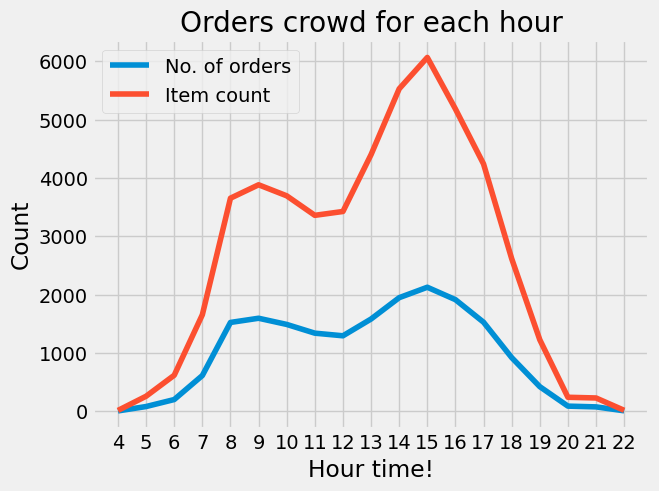

In [ ]:
print(data.hour.unique())
hour_idx = [i for i, _ in enumerate(data.hour.unique())]

print(hour_idx)
plt.plot(hour_idx, no_orders_hourly)
plt.plot(hour_idx,item_count_hourly)
plt.legend(["No. of orders", "Item count"])

plt.xticks(hour_idx, ["4","5", "6","7","8","9","10","11","12","13","14","15","16","17","18","19","20","21","22"])
plt.xlabel("Hour time!")
plt.ylabel("Count")
plt.title("Orders crowd for each hour")

In [ ]:
weekdata_group = data.groupby("weekday").count()

[5 6 0 1 2 3 4]


Text(0, 0.5, 'No. of orders')

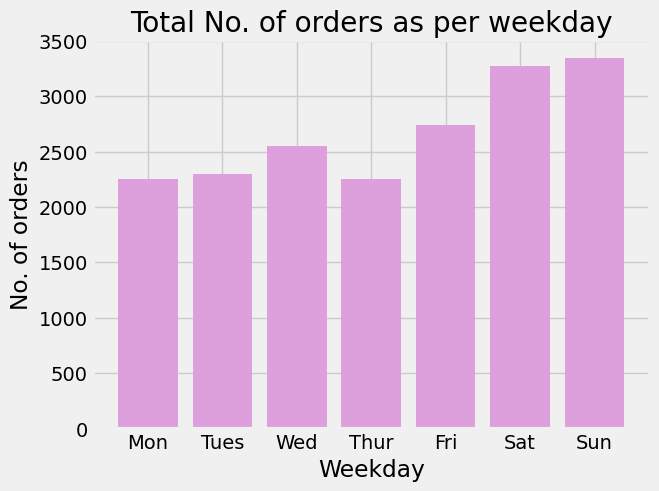

In [ ]:
print(data.weekday.unique())

weekday_idx = [i for i, _ in enumerate(data.weekday.unique())]

plt.bar(weekday_idx, weekdata_group["TIMESTAMP"].values, color='plum')
plt.xticks(weekday_idx, ["Mon", "Tues", "Wed", "Thur", "Fri", "Sat", "Sun"])
plt.title("Total No. of orders as per weekday")
plt.xlabel("Weekday")
plt.ylabel("No. of orders")

In [ ]:
print("No. of deliveries for which time gets exceeded from estimated delivery time: ", len(data[data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"] >0]))
print("No. of deliveries for which before estimated time: ", len(data[data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"] <0]))

No. of deliveries for which time gets exceeded from estimated delivery time:  7662
No. of deliveries for which before estimated time:  10255


[7662, 10255]


([<matplotlib.patches.Wedge at 0x7ff817782d90>,
 [Text(0.24791490578718373, 1.0716987447452442, 'LATE'),
  Text(-0.24791480544750455, -1.071698767956708, 'BEFORE-TIME')],
 [Text(0.13522631224755474, 0.584562951679224, '43%'),
  Text(-0.13522625751682066, -0.5845629643400225, '57%')])

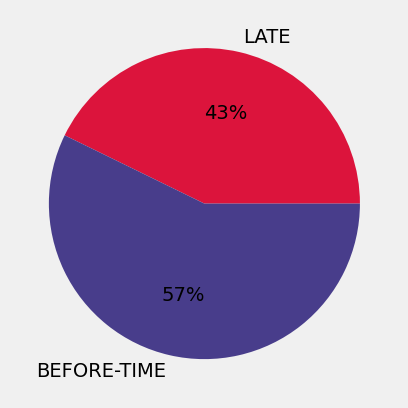

In [ ]:
sizes = [len(data[data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"] >0]), len(data[data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"] <0])]
labels = ["LATE", "BEFORE-TIME"]
print(sizes)
plt.pie(sizes, labels=labels, colors = ['crimson','darkslateblue'], autopct='%1.0f%%')

Text(0.5, 1.0, 'Delay time distribution')

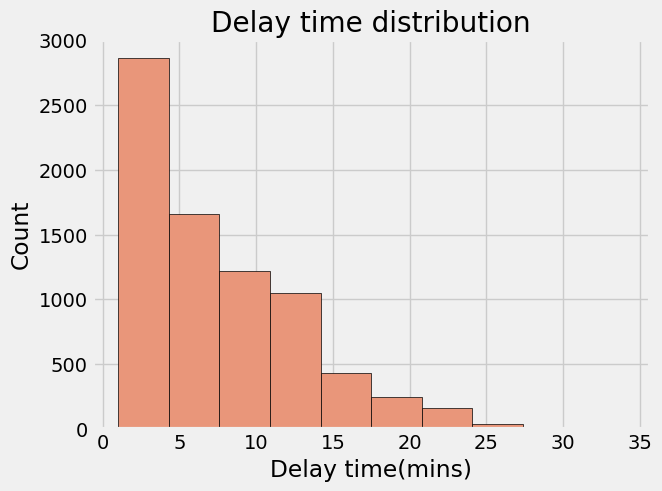

In [ ]:
plt.hist(data[data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"] >0]["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"], color="darksalmon", edgecolor='black')
plt.ylabel("Count")
plt.xlabel("Delay time(mins)")
plt.title("Delay time distribution")

In [ ]:
print("Maximum delay happened in delivery(minutes)", max(data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"]))
print("Minimum delay happened in delivery(minutes)", min(data[data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"]>0]["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"]))


Maximum delay happened in delivery(minutes) 34
Minimum delay happened in delivery(minutes) 1


In [ ]:
data.groupby(pd.cut(data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"], [0,10,20,30,40])).count()

<ipython-input-26-56c1a7b45553>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data["ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES"], [0,10,20,30,40])).count()


,TIMESTAMP,ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,ITEM_COUNT,USER_LAT,USER_LONG,VENUE_LAT,VENUE_LONG,ESTIMATED_DELIVERY_MINUTES,ACTUAL_DELIVERY_MINUTES,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,time,date,hour,weekday
ACTUAL_DELIVERY_MINUTES - ESTIMATED_DELIVERY_MINUTES,,,,,,,,,,,,,,,,,
"(0, 10]",5738,5738,5738,5738,5738,5738,5738,5738,5738,5656,5656,5656,5738,5738,5738,5738,5738
"(10, 20]",1719,1719,1719,1719,1719,1719,1719,1719,1719,1689,1689,1689,1719,1719,1719,1719,1719
"(20, 30]",200,200,200,200,200,200,200,200,200,196,196,196,200,200,200,200,200
"(30, 40]",5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5


In [ ]:
def calculate_dist_user_venue(coord1, coord2):
    distance_geopy = gd.distance(coord1, coord2).km
    return distance_geopy

In [ ]:
data["dist_user_venue"] = data.apply(lambda x: calculate_dist_user_venue((x["USER_LAT"], x["USER_LONG"]), (x["VENUE_LAT"], x["VENUE_LONG"])), axis=1)

In [ ]:
data["dist_user_venue"]

,dist_user_venue
0,0.222830
1,1.460344
2,0.157311
3,2.449984
4,0.556318
...,...
18701,0.055513
18702,0.827796
18703,0.447776
18704,0.449105


Text(0, 0.5, 'Count')

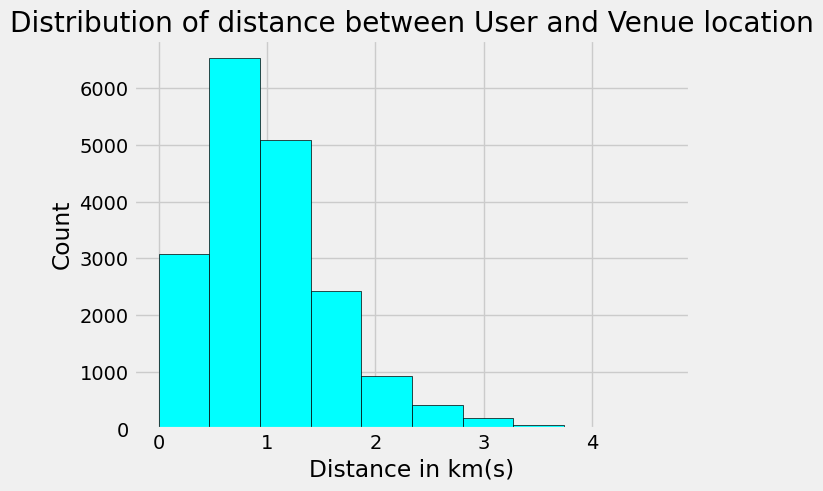

In [ ]:
plt.hist(data["dist_user_venue"], color="aqua", edgecolor='black')
plt.title("Distribution of distance between User and Venue location")
plt.xlabel("Distance in km(s)")
plt.ylabel("Count")

In [ ]:
df1 = data[["date","hour"]]

In [ ]:
df1["no_of_orders"] = 1

<ipython-input-32-28141704873b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["no_of_orders"] = 1


In [ ]:
import utility



In [ ]:
if ((df1["date"]==datetime.date(2020, 8, 1)) & (df1["hour"]==4)).any():
    print("Yes")
else:
    print("NO")

list_dates = df1.date.unique()
df1 = utility.fill_all_hour_data(df1, list_dates)


NO


In [ ]:
df1 = df1.sort_values(by=["date"])

In [ ]:
df1

,date,hour,no_of_orders
0,2020-08-01,6,1
205,2020-08-01,16,1
204,2020-08-01,16,1
203,2020-08-01,16,1
202,2020-08-01,16,1
...,...,...,...
18550,2020-09-30,14,1
18551,2020-09-30,14,1
18552,2020-09-30,14,1
18546,2020-09-30,14,1


In [ ]:
df1 = df1.set_index('date')
print("Dates which are missing", pd.date_range(
  start="2020-08-01", end="2020-09-30").difference(df1.index))
df1 = df1.reset_index()

Dates which are missing DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [ ]:
df1.groupby(["date", "hour"]).sum()

no_of_orders
date       hour              
2020-08-01 4                0
           5                0
           6                3
           7                6
           8               15
...                       ...
2020-09-30 18              19
           19               8
           20               1
           21               0
           22               0

[1159 rows x 1 columns]

In [ ]:
df_hourly_orders = df1.groupby(["date", "hour"]).sum().reset_index()["no_of_orders"]

In [ ]:
df_hourly_orders

,no_of_orders
0,0
1,0
2,3
3,6
4,15
...,...
1154,19
1155,8
1156,1
1157,0


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_hourly_orders)
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -4.665836319468874
p-value: 9.750825517005903e-05


Text(0.5, 1.0, 'All orders plot grouped by date and hour')

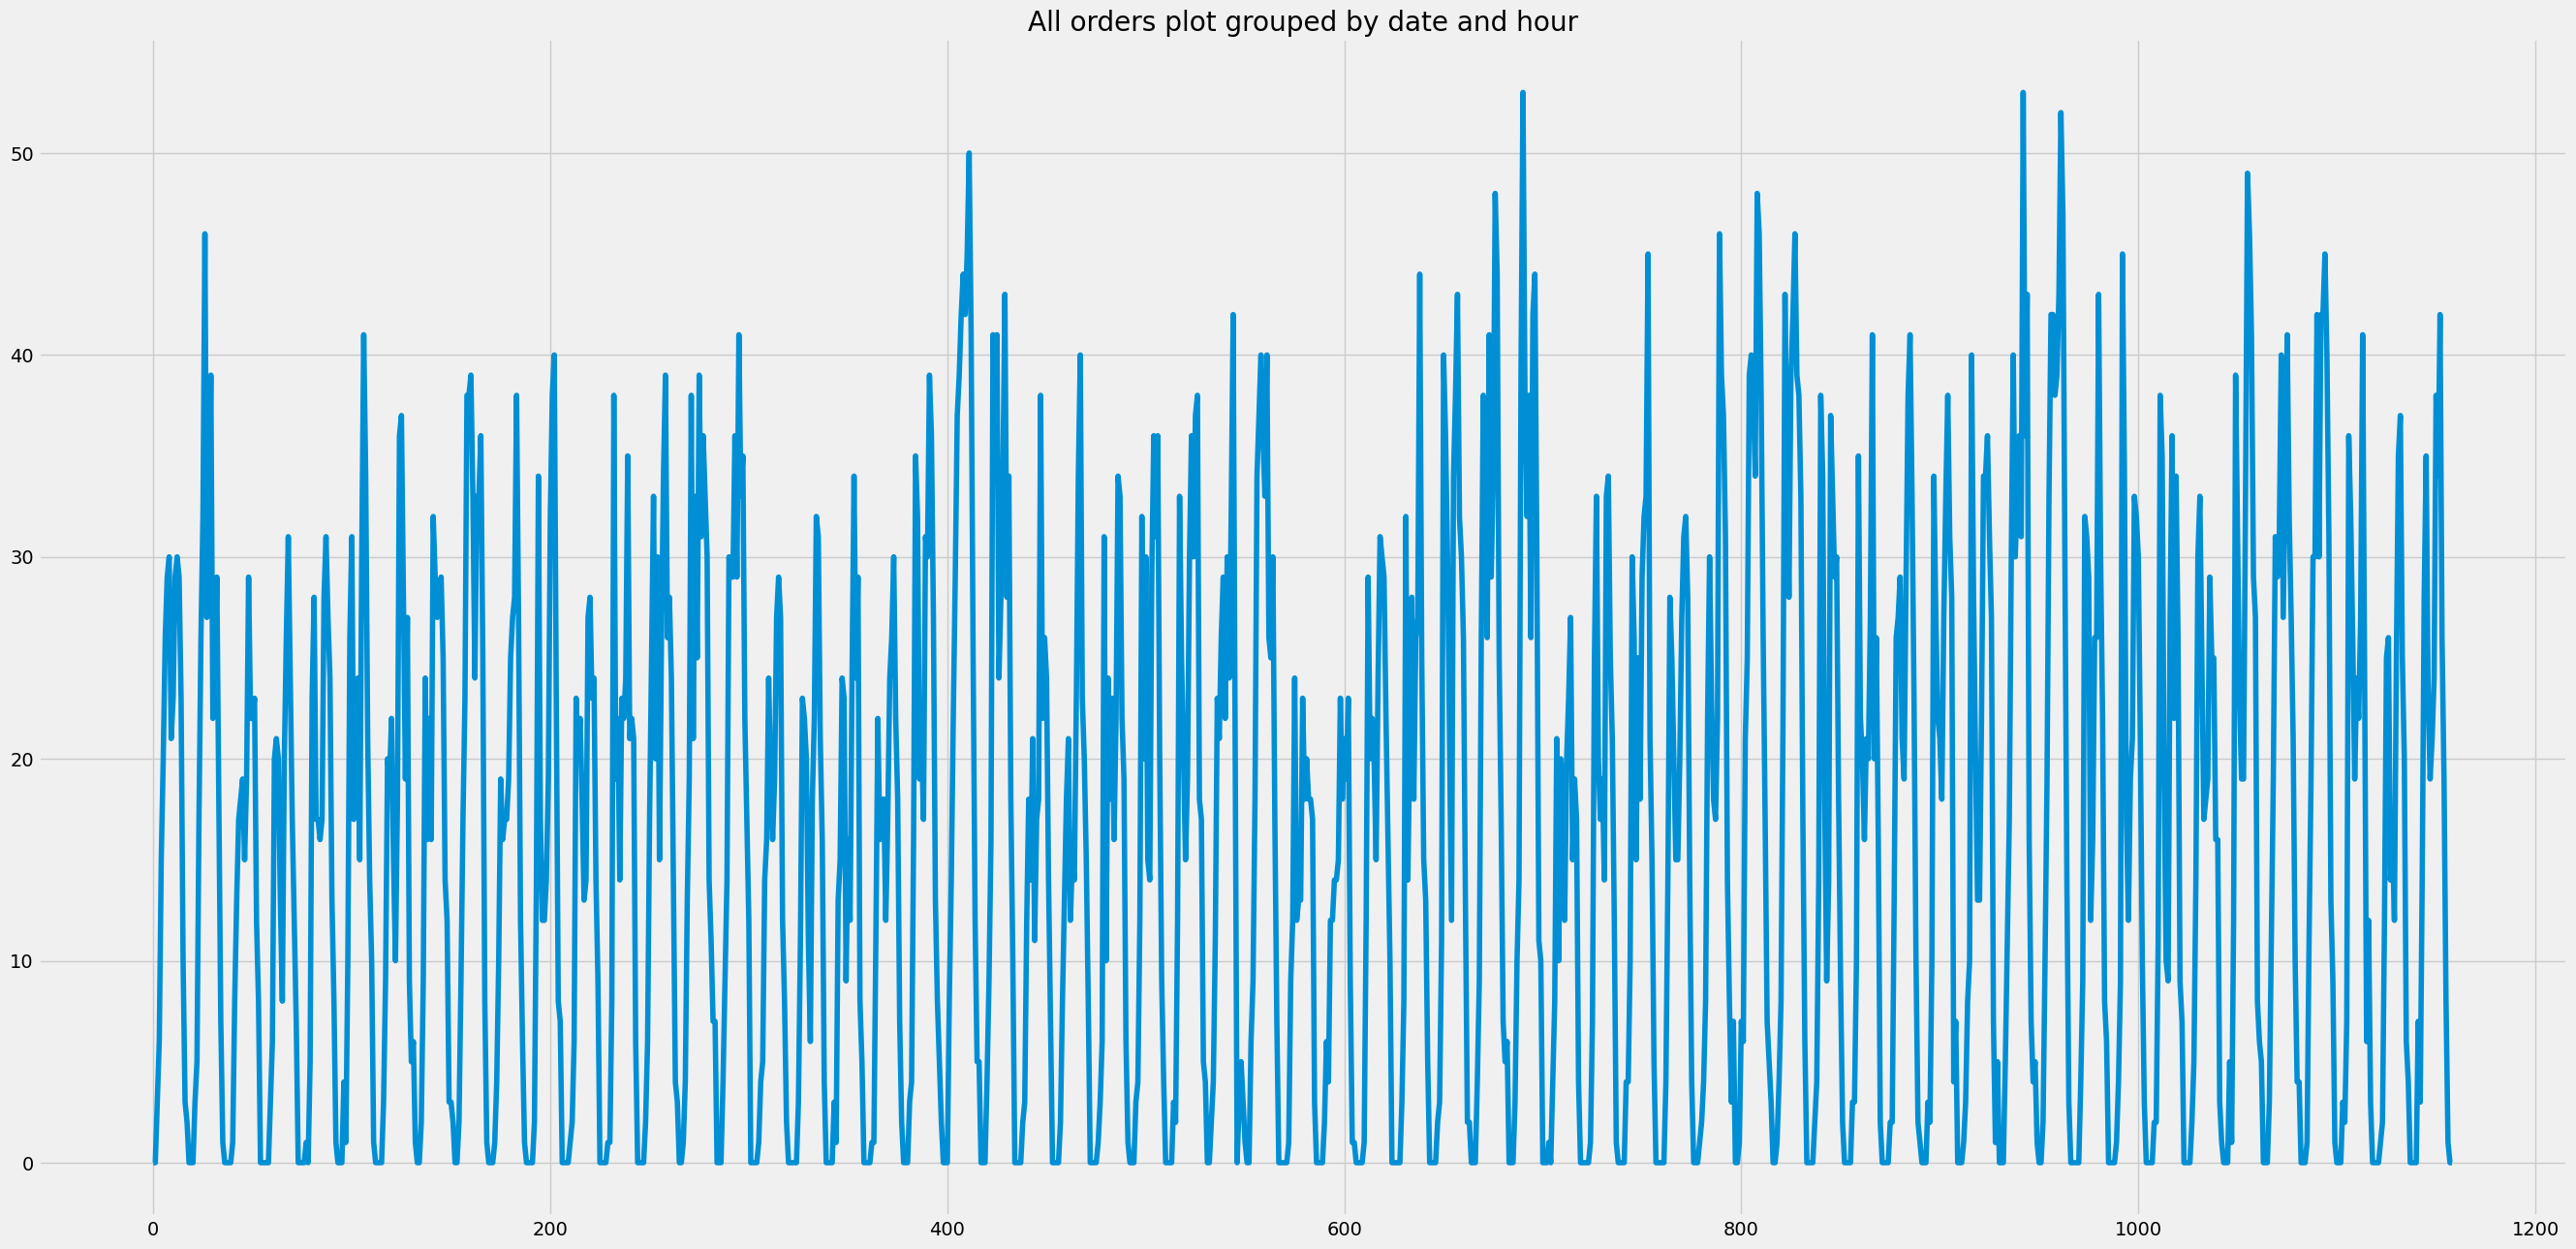

In [ ]:
plt.figure(figsize=(30,15))
plt.plot(df_hourly_orders)
plt.title("All orders plot grouped by date and hour")

In [ ]:

scaler=MinMaxScaler(feature_range=(0,1))
df_hourly_orders=scaler.fit_transform(np.array(df_hourly_orders).reshape(-1,1))

In [ ]:
df_hourly_orders

array([[0.        ],
       [0.        ],
       [0.05660377],
       ...,
       [0.01886792],
       [0.        ],
       [0.        ]])

In [ ]:
train_data, training_size, test_data, test_size = utility.train_test_split_(df_hourly_orders,0.65)


In [ ]:
training_size,test_size

(753, 406)

In [ ]:
time_step = 10
X_train, y_train = utility.dataset_creation(train_data, time_step)
X_test, ytest = utility.dataset_creation(test_data, time_step)

In [ ]:
print(X_train.shape), print(y_train.shape)

(742, 10)
(742,)


(None, None)

In [ ]:


X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [ ]:
 !pip install tensorflow

In [ ]:
 !pip install tensorflow==2.12 keras==2.12

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 7.4 MB/s eta 0:00:00
  Atte

In [ ]:
import tensorflow

In [ ]:

from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential

In [ ]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(10,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

In [ ]:
hist =  model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)


Epoch 1/100
12/12 [==============================] - 10s 171ms/step - loss: 0.0977 - val_loss: 0.0953
Epoch 2/100
12/12 [==============================] - 0s 31ms/step - loss: 0.0667 - val_loss: 0.0838
Epoch 3/100
12/12 [==============================] - 0s 33ms/step - loss: 0.0572 - val_loss: 0.0651
Epoch 4/100
12/12 [==============================] - 0s 34ms/step - loss: 0.0452 - val_loss: 0.0474
Epoch 5/100
12/12 [==============================] - 0s 32ms/step - loss: 0.0394 - val_loss: 0.0447
Epoch 6/100
12/12 [==============================] - 0s 31ms/step - loss: 0.0363 - val_loss: 0.0429
Epoch 7/100
12/12 [==============================] - 0s 33ms/step - loss: 0.0336 - val_loss: 0.0471
Epoch 8/100
12/12 [==============================] - 0s 31ms/step - loss: 0.0314 - val_loss: 0.0399
Epoch 9/100
12/12 [==============================] - 0s 32ms/step - loss: 0.0300 - val_loss: 0.0382
Epoch 10/100
12/12 [==============================] - 0s 35ms/step - loss: 0.0296 - val_loss: 0.03

In [ ]:
utility.save_json('history.json', hist.history)

In [ ]:
model.save("models/LSTMN_UNIVARIATE.h5")

[0.09531856328248978, 0.08375172317028046, 0.06506308168172836, 0.047392264008522034, 0.04467257857322693, 0.04294712096452713, 0.04713208228349686, 0.03990030288696289, 0.03824537247419357, 0.03707056865096092, 0.040560588240623474, 0.039009593427181244, 0.03563456982374191, 0.03628537431359291, 0.04131616652011871, 0.03597700968384743, 0.03418557718396187, 0.03786327317357063, 0.037576448172330856, 0.03275879845023155, 0.032672274857759476, 0.03623679280281067, 0.03496801480650902, 0.03404749557375908, 0.029526254162192345, 0.029285363852977753, 0.027227656915783882, 0.02679917961359024, 0.036128100007772446, 0.02628146857023239, 0.023800509050488472, 0.023046474903821945, 0.020770831033587456, 0.020710038021206856, 0.01924818940460682, 0.020633386448025703, 0.027170417830348015, 0.022485267370939255, 0.020505107939243317, 0.020148292183876038, 0.02177451178431511, 0.02010423131287098, 0.02171669900417328, 0.018772149458527565, 0.01590428128838539, 0.015168242156505585, 0.01335801929

Text(0.5, 1.0, 'Loss Curve of Univariate Time Series Model')

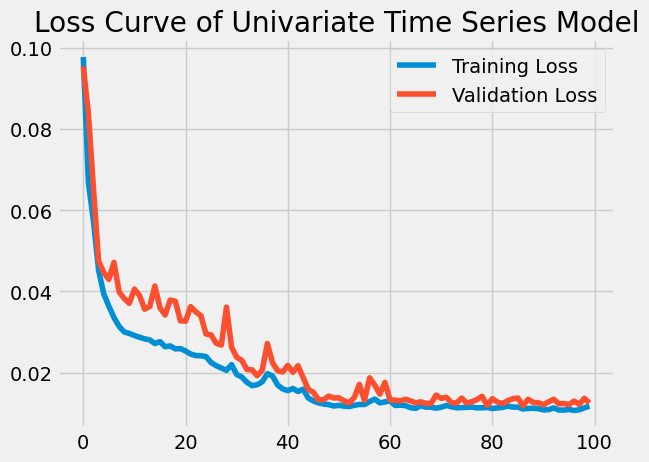

In [ ]:
with open('history.json', 'r') as f:
    hist_ = f.readlines()
print(ast.literal_eval(hist_[0])["val_loss"])
plt.plot(ast.literal_eval(hist_[0])["loss"])
plt.plot(ast.literal_eval(hist_[0])["val_loss"])
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss Curve of Univariate Time Series Model")

In [ ]:

train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

13/13 [==============================] - 0s 7ms/step


In [ ]:
print(test_predict)
print(scaler.inverse_transform(ytest.reshape(-1,1)))

[[ 8.46750546e+00]
 [ 2.30932293e+01]
 [ 2.89376564e+01]
 [ 2.29488583e+01]
 [ 2.00986519e+01]
 [ 2.09852562e+01]
 [ 2.35960903e+01]
 [ 2.73078842e+01]
 [ 2.82012005e+01]
 [ 2.44039822e+01]
 [ 2.04650478e+01]
 [ 1.64156609e+01]
 [ 8.30043793e+00]
 [ 1.84553611e+00]
 [-1.36140096e+00]
 [-1.41089940e+00]
 [-4.68604118e-01]
 [ 1.58251476e+00]
 [ 4.19258261e+00]
 [ 9.12269974e+00]
 [ 1.88117466e+01]
 [ 2.53885384e+01]
 [ 2.23244076e+01]
 [ 2.13355560e+01]
 [ 2.26796055e+01]
 [ 2.48340302e+01]
 [ 2.82971916e+01]
 [ 3.92903709e+01]
 [ 3.43700142e+01]
 [ 3.02163391e+01]
 [ 2.17702789e+01]
 [ 9.66563702e+00]
 [ 5.70392895e+00]
 [ 1.59914374e+00]
 [ 3.28025556e+00]
 [-4.62531745e-02]
 [ 1.07933950e+00]
 [ 2.07285118e+00]
 [ 7.16973734e+00]
 [ 1.34934330e+01]
 [ 2.67050152e+01]
 [ 2.81163578e+01]
 [ 3.23736115e+01]
 [ 3.72502098e+01]
 [ 3.65992622e+01]
 [ 3.61927910e+01]
 [ 4.32337112e+01]
 [ 4.38592796e+01]
 [ 3.78099174e+01]
 [ 1.93436146e+01]
 [ 9.60579681e+00]
 [ 3.70116067e+00]
 [ 2.4591081

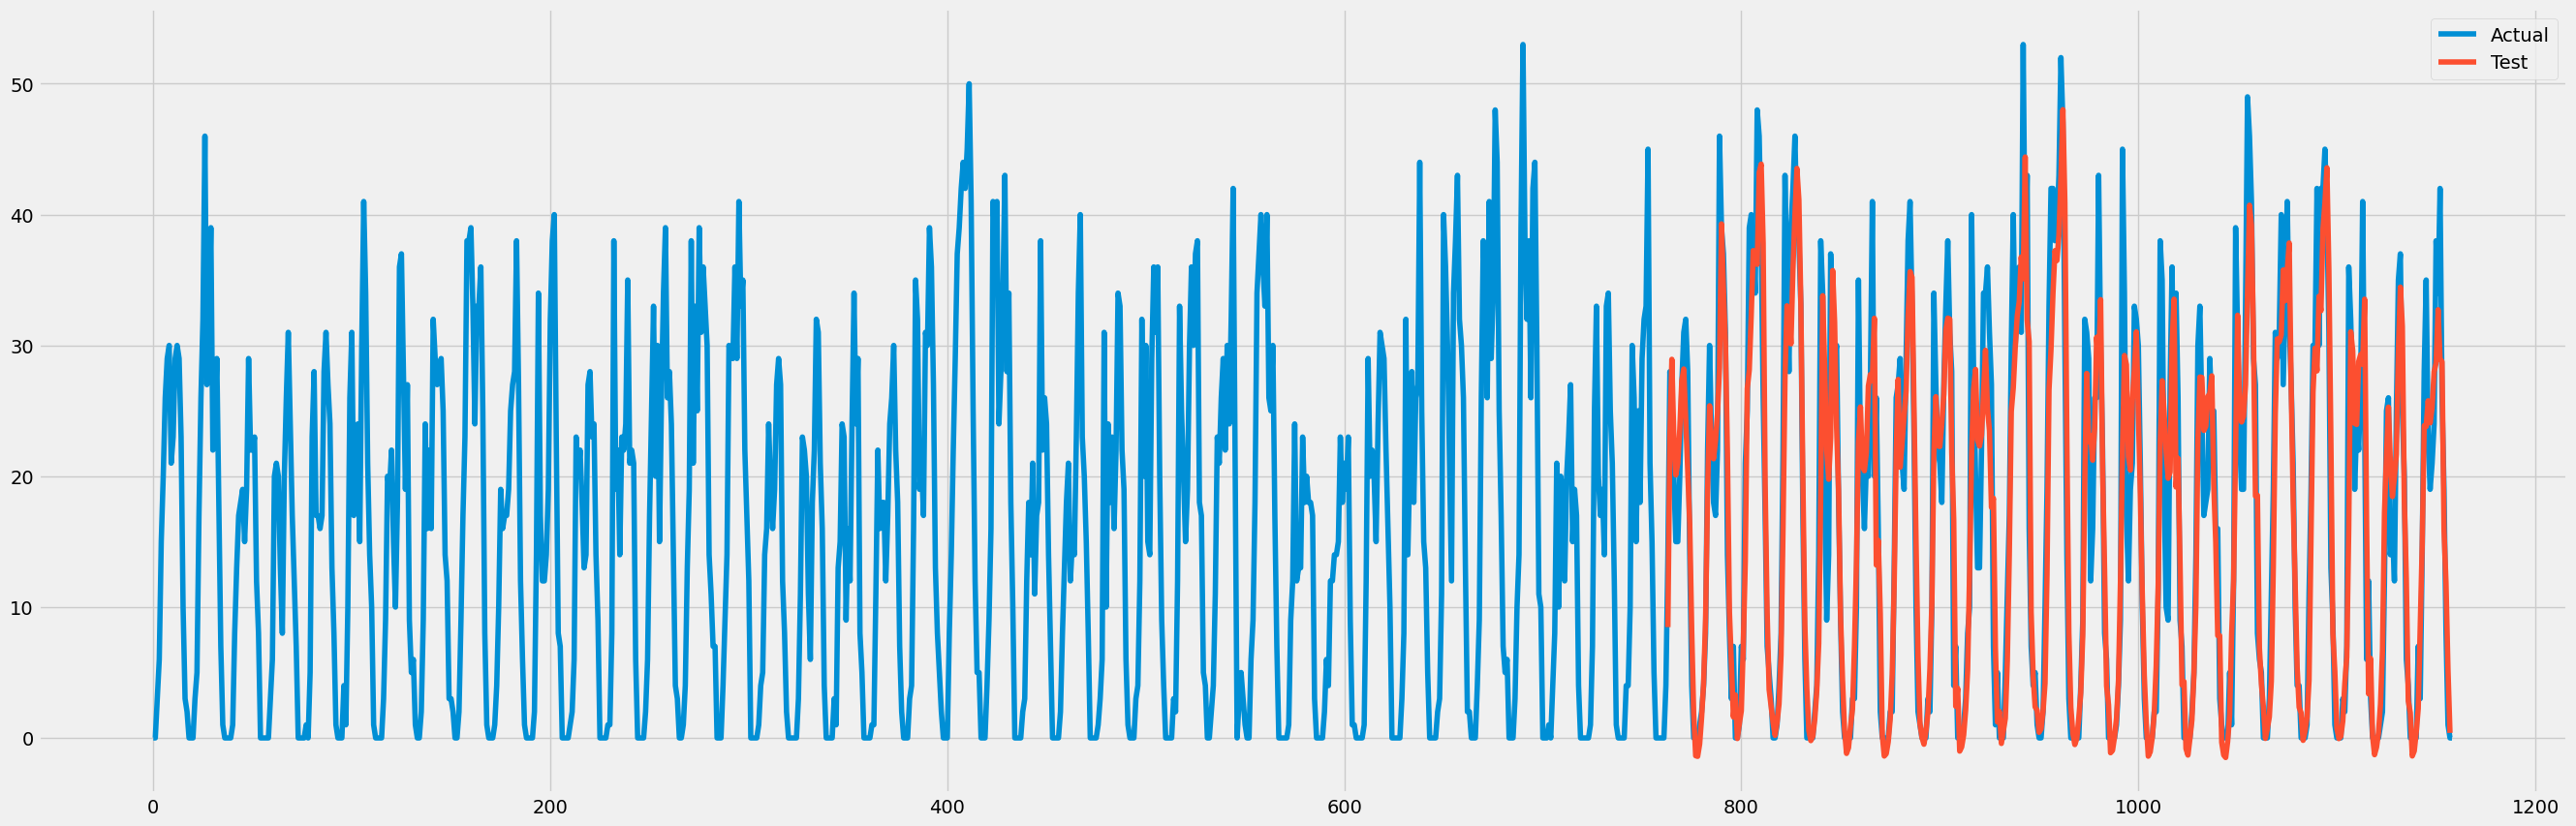

13/13 [==============================] - 0s 7ms/step


In [ ]:
plt.figure(figsize=(30,10))
look_back=10
trainPredictPlot = np.empty_like(df_hourly_orders)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

testPredictPlot = np.empty_like(df_hourly_orders)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df_hourly_orders)-1, :] = test_predict

plt.plot(scaler.inverse_transform(df_hourly_orders))
plt.plot(testPredictPlot)
plt.legend(["Actual","Test"])
plt.show()

train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)


In [ ]:
math.sqrt(mean_squared_error(ytest,test_predict))

17.02174682652839

In [ ]:
math.sqrt(mean_squared_error(y_train,train_predict))

19.53666939363611

In [ ]:
rmse = np.sqrt(mean_squared_error(ytest,test_predict))
print("RMSE: ", rmse)
# mae = mean_absolute_error(test, predicted)

RMSE:  17.02174682652839


In [ ]:
df2 = data[["date","hour","CLOUD_COVERAGE","TEMPERATURE","WIND_SPEED","PRECIPITATION"]]
df2["no_of_orders"] = 1

<ipython-input-62-fc3b11a56c00>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2["no_of_orders"] = 1


In [ ]:
print(df2.date.unique())

list_dates = df2.date.unique()

df2 = utility.fill_all_hour_data(df2, list_dates,ismultivariate=True)

[datetime.date(2020, 8, 1) datetime.date(2020, 8, 2)
 datetime.date(2020, 8, 3) datetime.date(2020, 8, 4)
 datetime.date(2020, 8, 5) datetime.date(2020, 8, 6)
 datetime.date(2020, 8, 7) datetime.date(2020, 8, 8)
 datetime.date(2020, 8, 9) datetime.date(2020, 8, 10)
 datetime.date(2020, 8, 11) datetime.date(2020, 8, 12)
 datetime.date(2020, 8, 13) datetime.date(2020, 8, 14)
 datetime.date(2020, 8, 15) datetime.date(2020, 8, 16)
 datetime.date(2020, 8, 17) datetime.date(2020, 8, 18)
 datetime.date(2020, 8, 19) datetime.date(2020, 8, 20)
 datetime.date(2020, 8, 21) datetime.date(2020, 8, 22)
 datetime.date(2020, 8, 23) datetime.date(2020, 8, 24)
 datetime.date(2020, 8, 25) datetime.date(2020, 8, 26)
 datetime.date(2020, 8, 27) datetime.date(2020, 8, 28)
 datetime.date(2020, 8, 29) datetime.date(2020, 8, 30)
 datetime.date(2020, 8, 31) datetime.date(2020, 9, 1)
 datetime.date(2020, 9, 2) datetime.date(2020, 9, 3)
 datetime.date(2020, 9, 4) datetime.date(2020, 9, 5)
 datetime.date(2020, 9, 

In [ ]:
df2

,date,hour,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION,no_of_orders
0,2020-08-01,6,0.0,15.0,3.53644,0.0,1
1,2020-08-01,6,0.0,15.0,3.53644,0.0,1
2,2020-08-01,6,0.0,15.0,3.53644,0.0,1
3,2020-08-01,7,0.0,16.7,3.52267,0.0,1
4,2020-08-01,7,0.0,16.7,3.52267,0.0,1
...,...,...,...,...,...,...,...
0,2020-09-29,21,0.0,0.0,0.00000,0.0,0
0,2020-09-29,22,0.0,0.0,0.00000,0.0,0
0,2020-09-30,4,0.0,0.0,0.00000,0.0,0
0,2020-09-30,21,0.0,0.0,0.00000,0.0,0


In [ ]:
multivariate_data = df2.groupby(["date","hour"]).aggregate({"no_of_orders":np.sum,"CLOUD_COVERAGE":np.mean,"TEMPERATURE":np.mean,"WIND_SPEED":np.mean,"PRECIPITATION":np.mean})

<ipython-input-65-7d534a752eb6>:1: FutureWarning: The provided callable <function sum at 0x7ff878389a80> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  multivariate_data = df2.groupby(["date","hour"]).aggregate({"no_of_orders":np.sum,"CLOUD_COVERAGE":np.mean,"TEMPERATURE":np.mean,"WIND_SPEED":np.mean,"PRECIPITATION":np.mean})
<ipython-input-65-7d534a752eb6>:1: FutureWarning: The provided callable <function mean at 0x7ff87838b100> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  multivariate_data = df2.groupby(["date","hour"]).aggregate({"no_of_orders":np.sum,"CLOUD_COVERAGE":np.mean,"TEMPERATURE":np.mean,"WIND_SPEED":np.mean,"PRECIPITATION":np.mean})


In [ ]:
multivariate_data

no_of_orders  CLOUD_COVERAGE  TEMPERATURE  WIND_SPEED  \
date       hour                                                          
2020-08-01 4                0             0.0          0.0     0.00000   
           5                0             0.0          0.0     0.00000   
           6                3             0.0         15.0     3.53644   
           7                6             0.0         16.7     3.52267   
           8               15            25.0         17.8     3.35088   
...                       ...             ...          ...         ...   
2020-09-30 18              19            45.0         12.8     2.24368   
           19               8             0.0         12.8     2.34419   
           20               1             0.0         12.8     2.34249   
           21               0             0.0          0.0     0.00000   
           22               0             0.0          0.0     0.00000   

                 PRECIPITATION  
date       hour                 
2020-08-01 4               0.0  
           5               0.0  
           6               0.0  
           7               0.0  
           8               0.0  
...                        ...  
2020-09-30 18              0.0  
           19              0.0  
           20              0.0  
           21              0.0  
           22              0.0  

[1159 rows x 5 columns]

In [ ]:
multivariate_data = multivariate_data.reset_index().drop(columns=["date","hour"])
multivariate_data

,no_of_orders,CLOUD_COVERAGE,TEMPERATURE,WIND_SPEED,PRECIPITATION
0,0,0.0,0.0,0.00000,0.0
1,0,0.0,0.0,0.00000,0.0
2,3,0.0,15.0,3.53644,0.0
3,6,0.0,16.7,3.52267,0.0
4,15,25.0,17.8,3.35088,0.0
...,...,...,...,...,...
1154,19,45.0,12.8,2.24368,0.0
1155,8,0.0,12.8,2.34419,0.0
1156,1,0.0,12.8,2.34249,0.0
1157,0,0.0,0.0,0.00000,0.0


In [ ]:
multivariate_data.isna().sum()

,0
no_of_orders,0
CLOUD_COVERAGE,14
TEMPERATURE,14
WIND_SPEED,14
PRECIPITATION,0


In [ ]:
multivariate_data = np.array(multivariate_data)

In [ ]:
multivariate_data.shape

(1159, 5)

In [ ]:
import numpy as np

# Assuming multivariate_data is a NumPy array

# Fill NaNs in column index 1 (CLOUD_COVERAGE)
multivariate_data[:, 1] = np.where(
    np.isnan(multivariate_data[:, 1]),
    np.nanmean(multivariate_data[:, 1]),
    multivariate_data[:, 1]
)

# Fill NaNs in column index 2 (TEMPERATURE)
multivariate_data[:, 2] = np.where(
    np.isnan(multivariate_data[:, 2]),
    np.nanmean(multivariate_data[:, 2]),
    multivariate_data[:, 2]
)

# Fill NaNs in column index 3 (WIND_SPEED)
multivariate_data[:, 3] = np.where(
    np.isnan(multivariate_data[:, 3]),
    np.nanmean(multivariate_data[:, 3]),
    multivariate_data[:, 3]
)



In [ ]:
multivariate_data.shape

(1159, 5)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Define column names (adjust if different)
columns = ['no_of_orders', 'CLOUD_COVERAGE', 'TEMPERATURE', 'WIND_SPEED', 'PRECIPITATION']

# Convert the NumPy array to a DataFrame
multivariate_data = pd.DataFrame(multivariate_data, columns=columns)

# Initialize the scalers dictionary
scalers = {}

# Scale each column individually
for col in multivariate_data.columns:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaled_values = scaler.fit_transform(multivariate_data[col].values.reshape(-1, 1))
    multivariate_data[col] = scaled_values.flatten()
    scalers['scaler_' + col] = scaler


In [ ]:
multivariate_data = np.array(multivariate_data)

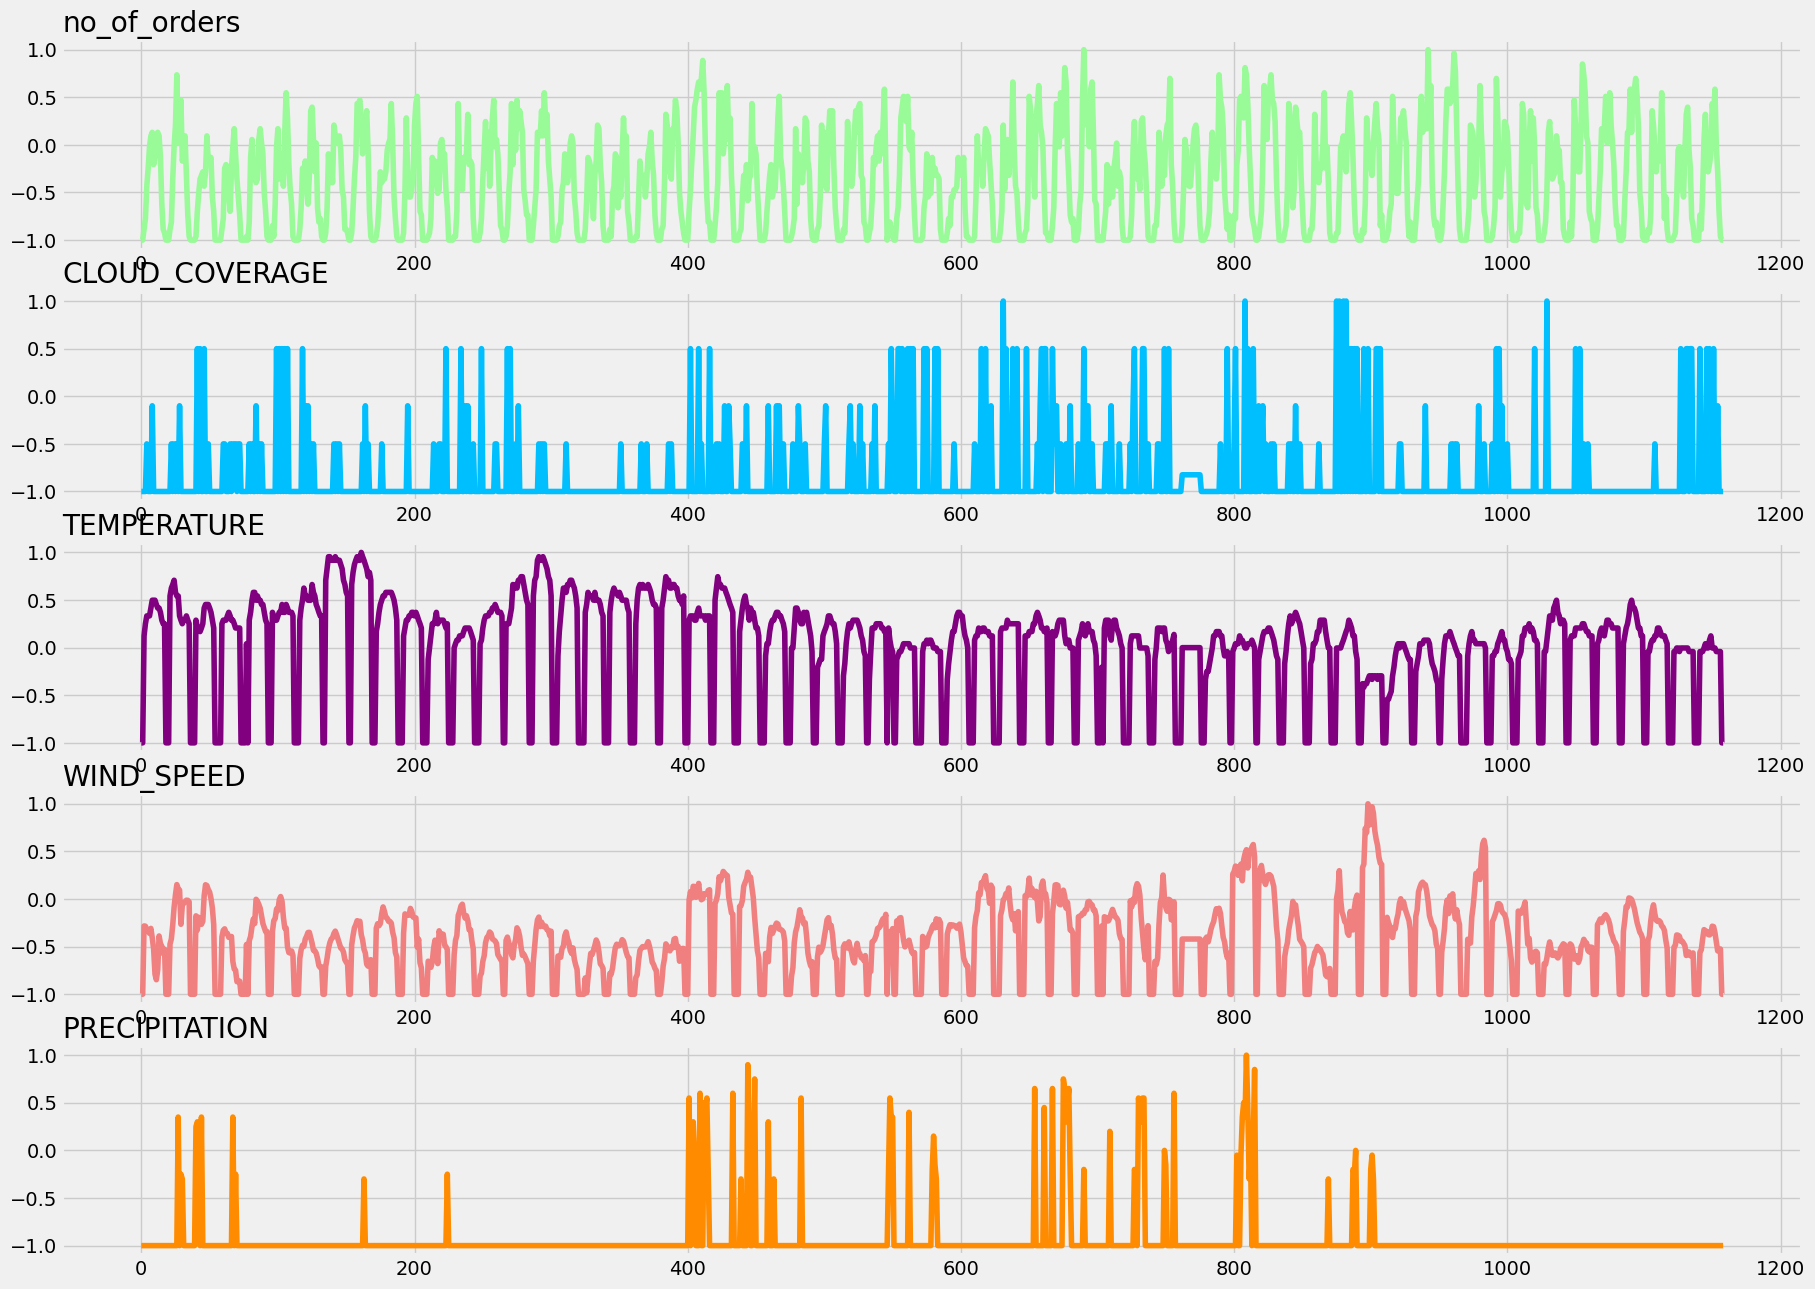

In [ ]:
groups = [0,1,2,3,4]
columns = ["no_of_orders", "CLOUD_COVERAGE", "TEMPERATURE", "WIND_SPEED", "PRECIPITATION"]
color = ['palegreen', 'deepskyblue', 'purple', 'lightcoral', 'darkorange']

i=1
plt.figure(figsize=(20,15))
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(multivariate_data[:, group], color=color[group])
    plt.title(columns[group], loc='left')
    i = i +1

plt.show()


In [ ]:
train_data, training_size, test_data, test_size = utility.train_test_split_multivariate(multivariate_data,0.65)

In [ ]:
time_step = 10
X_train, y_train = utility.dataset_creation(train_data, time_step, ismultivariate=True)
X_test, ytest = utility.dataset_creation(test_data, time_step, ismultivariate=True)

In [ ]:
import tensorflow

In [ ]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
opt = tensorflow.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss='mean_squared_error',optimizer=opt)

In [ ]:
hist =  model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=128,verbose=1)
# with open('history_multivariate.json', 'w') as f:
#     json.dump(hist.history, f)



Epoch 1/100
6/6 [==============================] - 10s 514ms/step - loss: 0.4039 - val_loss: 0.3983
Epoch 2/100
6/6 [==============================] - 0s 77ms/step - loss: 0.3733 - val_loss: 0.3769
Epoch 3/100
6/6 [==============================] - 0s 53ms/step - loss: 0.3452 - val_loss: 0.3587
Epoch 4/100
6/6 [==============================] - 0s 52ms/step - loss: 0.3209 - val_loss: 0.3433
Epoch 5/100
6/6 [==============================] - 0s 53ms/step - loss: 0.2990 - val_loss: 0.3312
Epoch 6/100
6/6 [==============================] - 0s 50ms/step - loss: 0.2803 - val_loss: 0.3223
Epoch 7/100
6/6 [==============================] - 0s 50ms/step - loss: 0.2656 - val_loss: 0.3166
Epoch 8/100
6/6 [==============================] - 0s 53ms/step - loss: 0.2541 - val_loss: 0.3137
Epoch 9/100
6/6 [==============================] - 0s 57ms/step - loss: 0.2463 - val_loss: 0.3123
Epoch 10/100
6/6 [==============================] - 0s 52ms/step - loss: 0.2398 - val_loss: 0.3100
Epoch 11/100
6/6 

In [ ]:
utility.save_json('history_multivariate.json',hist.history)

In [ ]:
import json


In [ ]:
import ast

with open('history_multivariate.json', 'r') as f:
    data = f.read()  # Read full content, not line-by-line
    hist_ = ast.literal_eval(data)

print(hist_["val_loss"])


[0.3982982337474823, 0.3769206702709198, 0.358663409948349, 0.34332847595214844, 0.3312046527862549, 0.32228872179985046, 0.31660667061805725, 0.3136714696884155, 0.3122577667236328, 0.3099766671657562, 0.30688562989234924, 0.3026605248451233, 0.29739952087402344, 0.2911987602710724, 0.28489595651626587, 0.2788270115852356, 0.2726361155509949, 0.2663751542568207, 0.26080143451690674, 0.2542479634284973, 0.24791280925273895, 0.2412947714328766, 0.23559115827083588, 0.2294139564037323, 0.22337459027767181, 0.2187872976064682, 0.21512478590011597, 0.21108996868133545, 0.20809167623519897, 0.20484237372875214, 0.20277132093906403, 0.20317377150058746, 0.1986035257577896, 0.1964709758758545, 0.1962772160768509, 0.19550670683383942, 0.19390437006950378, 0.19403807818889618, 0.19243304431438446, 0.19577395915985107, 0.1920030415058136, 0.19378839433193207, 0.19240009784698486, 0.19504769146442413, 0.19374491274356842, 0.19541922211647034, 0.1924860179424286, 0.19310317933559418, 0.19338101148

In [ ]:
with open('history_multivariate.json', 'r') as f:
    print(f.read())


{"loss": [0.40391889214515686, 0.37326040863990784, 0.34517988562583923, 0.3209143877029419, 0.29897019267082214, 0.2803446352481842, 0.26564881205558777, 0.2540569603443146, 0.2462841123342514, 0.23981796205043793, 0.23579995334148407, 0.23169070482254028, 0.2275383472442627, 0.2231503129005432, 0.2185630351305008, 0.21427765488624573, 0.20990817248821259, 0.20529158413410187, 0.2009766548871994, 0.19582436978816986, 0.19118279218673706, 0.18669424951076508, 0.18271814286708832, 0.17806972563266754, 0.17437781393527985, 0.17097049951553345, 0.16771604120731354, 0.1643720418214798, 0.1613629013299942, 0.15826351940631866, 0.15515536069869995, 0.15265554189682007, 0.1494593322277069, 0.14664778113365173, 0.1439727544784546, 0.1414104849100113, 0.13908059895038605, 0.1369657665491104, 0.13526663184165955, 0.13345061242580414, 0.13185161352157593, 0.13044977188110352, 0.129333034157753, 0.12838608026504517, 0.1277860403060913, 0.126966655254364, 0.12626533210277557, 0.12577398121356964, 0

In [ ]:
model.compile(optimizer='adam', loss='huber', metrics=['mae'])


In [ ]:
import json

with open('history_multivariate.json', 'r') as f:
    hist_ = json.load(f)

print(hist_.keys())  # Check available keys


dict_keys(['loss', 'val_loss'])


[0.3982982337474823, 0.3769206702709198, 0.358663409948349, 0.34332847595214844, 0.3312046527862549, 0.32228872179985046, 0.31660667061805725, 0.3136714696884155, 0.3122577667236328, 0.3099766671657562, 0.30688562989234924, 0.3026605248451233, 0.29739952087402344, 0.2911987602710724, 0.28489595651626587, 0.2788270115852356, 0.2726361155509949, 0.2663751542568207, 0.26080143451690674, 0.2542479634284973, 0.24791280925273895, 0.2412947714328766, 0.23559115827083588, 0.2294139564037323, 0.22337459027767181, 0.2187872976064682, 0.21512478590011597, 0.21108996868133545, 0.20809167623519897, 0.20484237372875214, 0.20277132093906403, 0.20317377150058746, 0.1986035257577896, 0.1964709758758545, 0.1962772160768509, 0.19550670683383942, 0.19390437006950378, 0.19403807818889618, 0.19243304431438446, 0.19577395915985107, 0.1920030415058136, 0.19378839433193207, 0.19240009784698486, 0.19504769146442413, 0.19374491274356842, 0.19541922211647034, 0.1924860179424286, 0.19310317933559418, 0.19338101148

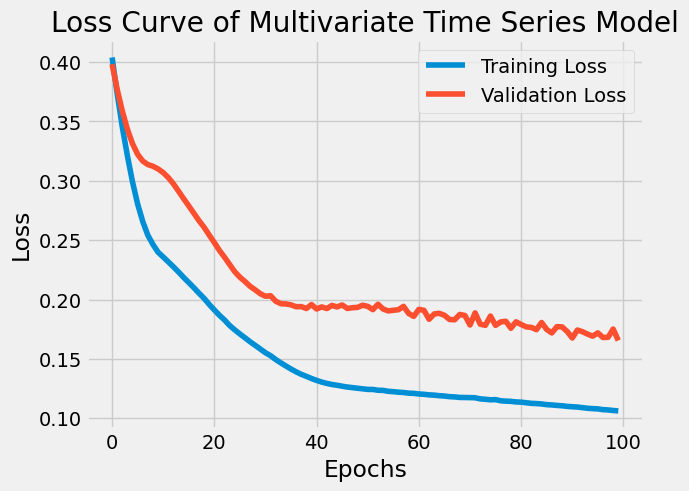

In [ ]:
import json
import matplotlib.pyplot as plt


with open('history_multivariate.json', 'r') as f:
    hist_ = json.load(f)


print(hist_["val_loss"])


plt.plot(hist_["loss"])
plt.plot(hist_["val_loss"])
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss Curve of Multivariate Time Series Model")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


[0.3982982337474823, 0.3769206702709198, 0.358663409948349, 0.34332847595214844, 0.3312046527862549, 0.32228872179985046, 0.31660667061805725, 0.3136714696884155, 0.3122577667236328, 0.3099766671657562, 0.30688562989234924, 0.3026605248451233, 0.29739952087402344, 0.2911987602710724, 0.28489595651626587, 0.2788270115852356, 0.2726361155509949, 0.2663751542568207, 0.26080143451690674, 0.2542479634284973, 0.24791280925273895, 0.2412947714328766, 0.23559115827083588, 0.2294139564037323, 0.22337459027767181, 0.2187872976064682, 0.21512478590011597, 0.21108996868133545, 0.20809167623519897, 0.20484237372875214, 0.20277132093906403, 0.20317377150058746, 0.1986035257577896, 0.1964709758758545, 0.1962772160768509, 0.19550670683383942, 0.19390437006950378, 0.19403807818889618, 0.19243304431438446, 0.19577395915985107, 0.1920030415058136, 0.19378839433193207, 0.19240009784698486, 0.19504769146442413, 0.19374491274356842, 0.19541922211647034, 0.1924860179424286, 0.19310317933559418, 0.19338101148

Text(0.5, 1.0, 'Loss Curve of Multivariate Time Series Model')

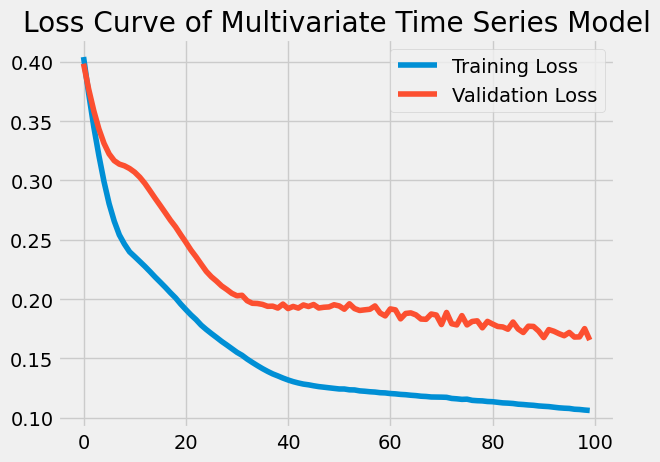

In [ ]:
with open('history_multivariate.json', 'r') as f:
    hist_ = f.readlines()
print(ast.literal_eval(hist_[0])["val_loss"])
plt.plot(ast.literal_eval(hist_[0])["loss"])
plt.plot(ast.literal_eval(hist_[0])["val_loss"])
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss Curve of Multivariate Time Series Model")


In [ ]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

train_predict=scalers['scaler_no_of_orders'].inverse_transform(train_predict)
test_predict=scalers['scaler_no_of_orders'].inverse_transform(test_predict)

13/13 [==============================] - 0s 10ms/step


In [ ]:
print(test_predict)
print(scaler.inverse_transform(ytest.reshape(-1,1)))

[[ 3.06853795e+00]
 [ 1.39085045e+01]
 [ 1.77543221e+01]
 [ 2.05403671e+01]
 [ 2.16144485e+01]
 [ 2.27356148e+01]
 [ 2.36091957e+01]
 [ 2.37007084e+01]
 [ 2.20523376e+01]
 [ 1.72753983e+01]
 [ 1.22556400e+01]
 [ 9.97323322e+00]
 [ 1.22704840e+01]
 [ 1.33468456e+01]
 [ 1.18203211e+01]
 [ 7.60064793e+00]
 [ 2.93345237e+00]
 [ 1.05039859e+00]
 [ 3.39868832e+00]
 [ 8.64015675e+00]
 [ 1.48684902e+01]
 [ 2.00963612e+01]
 [ 2.23630180e+01]
 [ 2.30094357e+01]
 [ 2.40983906e+01]
 [ 2.46378899e+01]
 [ 2.38226128e+01]
 [ 2.18512516e+01]
 [ 1.87480183e+01]
 [ 1.43651085e+01]
 [ 9.67831421e+00]
 [ 8.21408844e+00]
 [ 8.29008293e+00]
 [ 5.79247618e+00]
 [ 1.27102637e+00]
 [-4.11846113e+00]
 [-7.79844332e+00]
 [-4.22272861e-01]
 [ 7.61606216e+00]
 [ 1.67022552e+01]
 [ 2.37595596e+01]
 [ 2.68033257e+01]
 [ 2.87534008e+01]
 [ 2.79193344e+01]
 [ 2.94240856e+01]
 [ 2.87470074e+01]
 [ 2.52385044e+01]
 [ 2.15136070e+01]
 [ 1.80738468e+01]
 [ 1.29915905e+01]
 [ 1.13776550e+01]
 [ 1.00835075e+01]
 [ 1.0812624

In [ ]:
multivariate_data[:,0]

array([-1.        , -1.        , -0.88679245, ..., -0.96226415,
       -1.        , -1.        ])

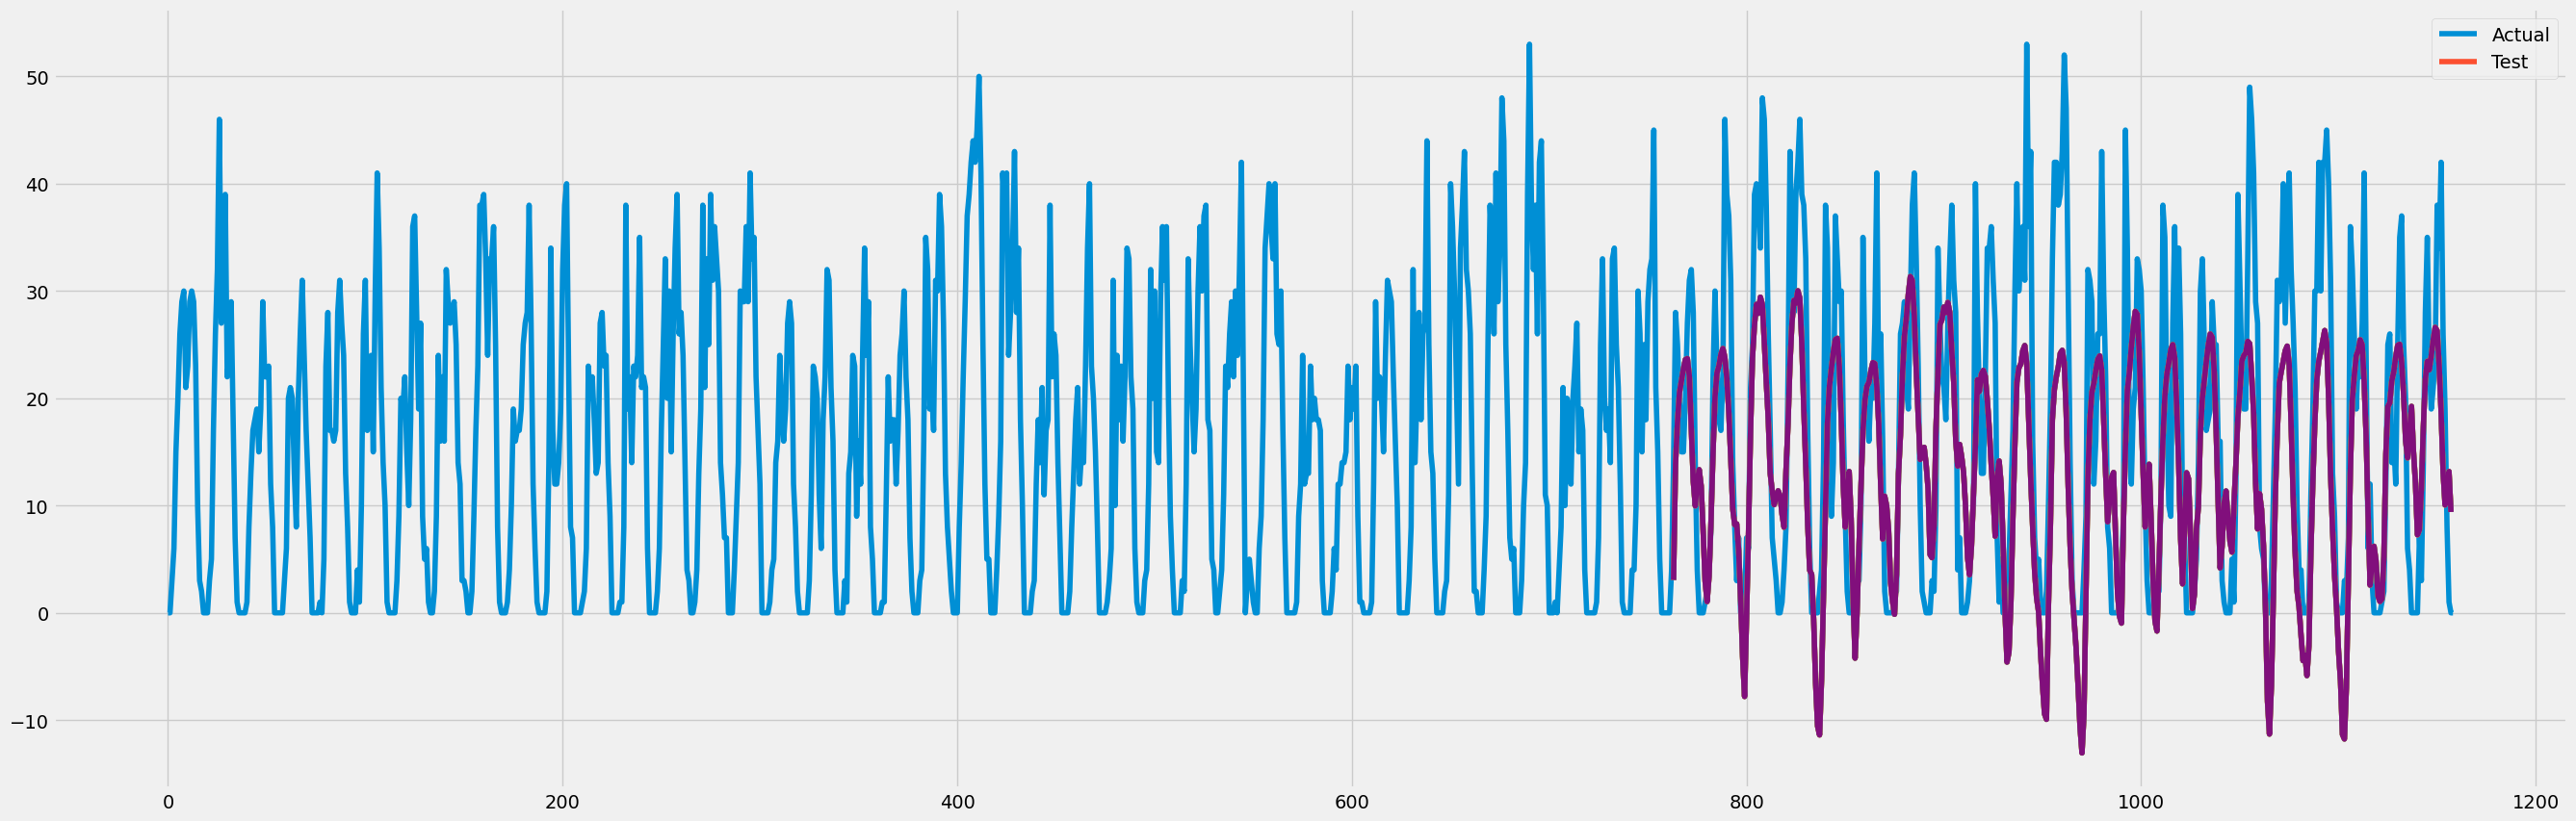

In [ ]:
plt.figure(figsize=(30,10))
look_back=10
trainPredictPlot = np.empty_like(multivariate_data)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict

testPredictPlot = np.empty_like(multivariate_data)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(multivariate_data)-1, :] = test_predict

plt.plot(scalers['scaler_no_of_orders'].inverse_transform(multivariate_data[:,0].reshape(-1,1)))
plt.plot(testPredictPlot)
plt.legend(["Actual","Test"])
plt.show()


In [ ]:
math.sqrt(mean_squared_error(ytest,test_predict))

17.02174682652839

In [ ]:
import tensorflow

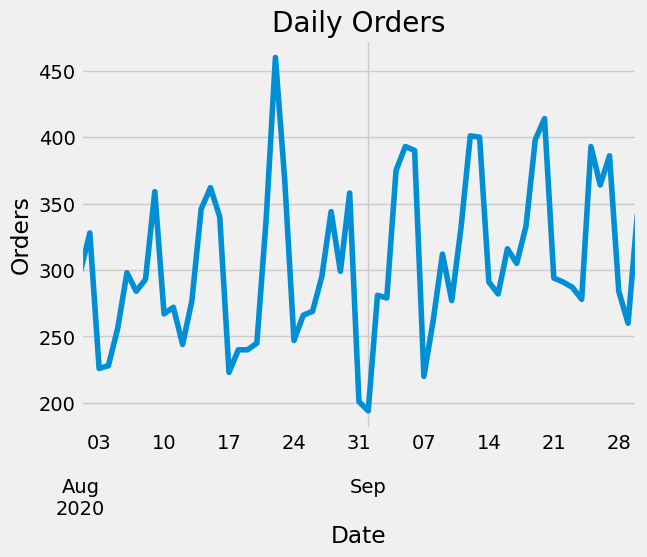

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=673.457, Time=0.02 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=631.930, Time=0.31 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=644.723, Time=0.16 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=875.827, Time=0.01 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=0.61 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,1)(1,0,1)[7]             : AIC=644.977, Time=0.33 sec

Best model:  ARIMA(0,0,1)(1,0,1)[7] intercept
Total fit time: 13.297 seconds


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:                      no_of_orders   No. Observations:                   61
Model:             SARIMAX(0, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -272.713
Date:                           Tue, 29 Apr 2025   AIC                            553.425
Time:                                   03:32:45   BIC                            561.230
Sample:                               08-01-2020   HQIC                           556.417
                                    - 09-30-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1        -13.4939     35.415     -0.381      0.703     -82.906      55.918
ar.S.L7        1.0115      0.020     51.430

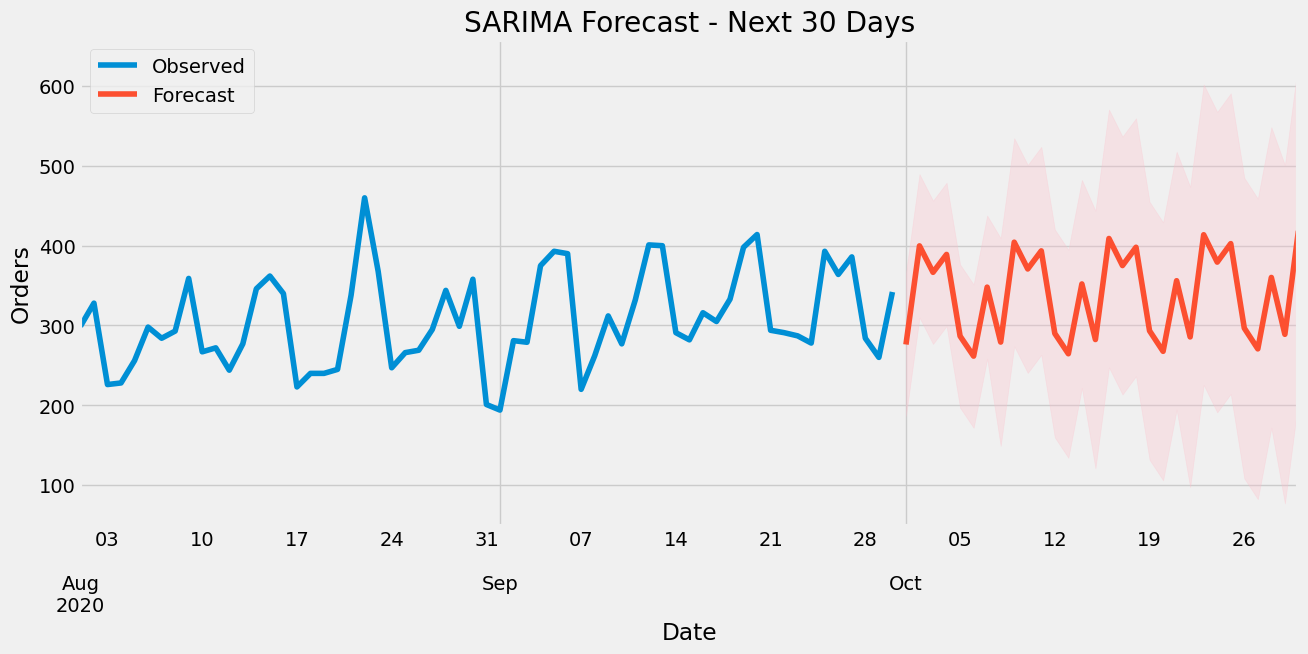

In [ ]:

df1['datetime'] = pd.to_datetime(df1['date']) + pd.to_timedelta(df1['hour'], unit='h')


df_daily = df1.set_index("datetime").resample("D")["no_of_orders"].sum()



df_daily.plot(title="Daily Orders")
plt.xlabel("Date")
plt.ylabel("Orders")
plt.show()


stepwise_fit = auto_arima(df_daily,
                          seasonal=True,
                          m=7,
                          trace=True,
                          suppress_warnings=True)


model = SARIMAX(df_daily,
                order=stepwise_fit.order,
                seasonal_order=stepwise_fit.seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


print(results.summary())


forecast = results.get_forecast(steps=30)
pred_ci = forecast.conf_int()


ax = df_daily.plot(label='Observed', figsize=(14, 6))
forecast.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Orders')
plt.title("SARIMA Forecast - Next 30 Days")
plt.legend()
plt.show()



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

train = df_daily[:-30]
test = df_daily[-30:]


model = SARIMAX(train,
                order=stepwise_fit.order,
                seasonal_order=stepwise_fit.seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()


forecast = results.get_forecast(steps=30)
predicted = forecast.predicted_mean


mse = mean_squared_error(test, predicted)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test, predicted)

print(f"📊 Evaluation Metrics:")
print(f"✅ MSE  = {mse:.2f}")
print(f"✅ RMSE = {rmse:.2f}")
print(f"✅ MAE  = {mae:.2f}")


📊 Evaluation Metrics:
✅ MSE  = 1162.42
✅ RMSE = 34.09
✅ MAE  = 28.65


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print("Mean Actual Orders:", df_daily.mean())


Mean Actual Orders: 306.655737704918


In [ ]:
print(df1.columns)
df1.head()


Index(['date', 'hour', 'no_of_orders', 'datetime'], dtype='object')


,date,hour,no_of_orders,datetime
0,2020-08-01,6,1,2020-08-01 06:00:00
1,2020-08-01,16,1,2020-08-01 16:00:00
2,2020-08-01,16,1,2020-08-01 16:00:00
3,2020-08-01,16,1,2020-08-01 16:00:00
4,2020-08-01,16,1,2020-08-01 16:00:00
